# LoRA Fine-tune Gemma 4 E2B — Resume-Job Matcher
Runs on Colab A100 (40 GB).

**Changes from v1:**
- ❌ Removed Optuna hyperparameter search (biggest speed-up)
- ✅ Best params baked in directly
- ✅ `lora_dropout=0.05` added (was 0 — fixes overfitting)
- ✅ `target_modules` narrowed to `q_proj, v_proj` (reduces capacity / overfit risk)
- ✅ `weight_decay=0.05` added for L2 regularization
- ✅ Early stopping added — auto-restores best checkpoint (catches your ~500-step peak)
- ✅ `load_in_4bit=False` kept — BF16 is correct for A100 40GB with a 2B model

In [ ]:
# Cell 1 — Install
# Install Unsloth directly from GitHub to bypass the latest pip dependency conflicts
%pip install --quiet "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%pip install --quiet --upgrade unsloth_zoo
%pip install --quiet --upgrade wandb protobuf
# Pin trl and datasets to versions compatible with Unsloth
%pip install --quiet "datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1" "trl!=0.19.0,<=0.24.0,>=0.18.2"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 7.8 MB/s e

In [ ]:
# Cell 2 — Mount Drive and set data path
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/finetune_data'

Mounted at /content/drive


In [ ]:
# Cell 3 — Load model + apply LoRA
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-4-e2b-it",
    max_seq_length=3072,
    load_in_4bit=False,  # BF16 full precision — A100 has 40GB, no need to quantize a 2B model
)

model = FastLanguageModel.get_peft_model(
    model,
    r=8,                # Increased from 8 — more capacity to learn scoring/classification
    lora_alpha=16,       # Keep at 2x rank
    lora_dropout=0.1,
    target_modules=[     # Full attention + MLP — needed for nuanced judgment tasks
        "q_proj",  "v_proj", "o_proj", #"k_proj",  # Attention
        #"gate_proj", "up_proj", "down_proj",        # MLP
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
)
print("Model loaded and LoRA applied.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Model loaded and LoRA applied.


In [ ]:
# Cell 4 — Load dataset
import os
from datasets import load_dataset

ds = load_dataset("json", data_files={
    "train": os.path.join(DATA_DIR, "train.jsonl"),
    "validation": os.path.join(DATA_DIR, "val.jsonl"),
})
print(ds)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 9000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 997
    })
})


In [ ]:
# Cell 5 — Verify sequence lengths against budget (sanity check before training)
import numpy as np

sample = ds["train"].select(range(min(500, len(ds["train"]))))
tok = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
lengths = [len(tok.encode(ex["text"])) for ex in sample if ex["text"]]
print(f"median={int(np.median(lengths))}  p95={int(np.percentile(lengths, 95))}  "
      f"p99={int(np.percentile(lengths, 99))}  max={max(lengths)}")
over = sum(1 for l in lengths if l > 3072)
print(f"{over}/{len(lengths)} sample rows exceed 3072 tokens")

median=1468  p95=1603  p99=1648  max=1767
0/500 sample rows exceed 3072 tokens


In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=3072,

        # --- Batch / throughput ---
        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,      # Effective batch = 32

        # --- Regularization ---
        learning_rate=1e-5,
        weight_decay=0.05,
        lr_scheduler_type="cosine",
        warmup_steps=100,

        # --- Training length ---
        num_train_epochs=3,

        # --- Precision ---
        bf16=True,

        # --- Logging & eval ---
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=50,

        # --- Checkpointing ---
        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        output_dir="outputs",
        report_to="none",
    ),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Unsloth's built-in way to mask prompts and compute loss only on the model response
trainer = train_on_responses_only(
    trainer,
    instruction_part="<start_of_turn>user\n",
    response_part="<start_of_turn>model\n",
)

trainer.train(resume_from_checkpoint=True)
print("\nTraining complete.")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/9000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/997 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/9000 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/9000 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/997 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/997 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,000 | Num Epochs = 3 | Total steps = 846
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 3,735,552 of 5,126,913,568 (0.07% trained)


Step,Training Loss,Validation Loss
250,0.877495,1.752600
300,0.828754,1.694880
350,0.720627,1.659227
400,0.677893,1.639315
450,0.636870,1.639096
500,0.611315,1.656442
550,0.592944,1.666377
600,0.609851,1.680629


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-350/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-450/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-550/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-600/tokenizer_config.json.



Training complete.


In [ ]:
import psutil
import time

uptime_seconds = time.time() - psutil.boot_time()
uptime_hours = uptime_seconds / 3600

print(f"Instance Uptime: {uptime_hours:.2f} hours")
print("Note: Colab Pro/Pro+ sessions typically last 12-24 hours. Check your 'Compute' tab in the top right for your exact Compute Unit balance.")

Instance Uptime: 3.91 hours
Note: Colab Pro/Pro+ sessions typically last 12-24 hours. Check your 'Compute' tab in the top right for your exact Compute Unit balance.


Loading state from: outputs/checkpoint-600/trainer_state.json
Training stopped at step : 600
Final train loss         : 0.6099
Final eval  loss         : 1.6806
Best eval   loss         : 1.6391 at step 450


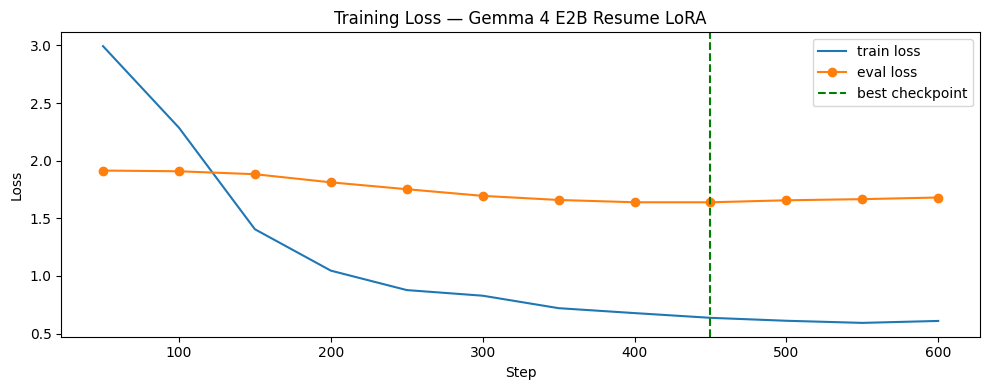

Saved training_loss.png and trainer_state.json to Drive


In [ ]:
# Cell 6b — Save training loss chart + artifacts to Drive
import json, os, shutil, glob
import matplotlib.pyplot as plt

# Fix: Find the latest checkpoint directory to get the trainer_state.json
checkpoint_dirs = glob.glob("outputs/checkpoint-*")
if not checkpoint_dirs:
    raise FileNotFoundError("No checkpoint directories found in 'outputs/'. Ensure training has run long enough to save.")

latest_checkpoint = max(checkpoint_dirs, key=os.path.getmtime)
state_path = os.path.join(latest_checkpoint, "trainer_state.json")

print(f"Loading state from: {state_path}")
with open(state_path) as f:
    state = json.load(f)

train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []
for entry in state["log_history"]:
    if "loss" in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

print(f"Training stopped at step : {train_steps[-1]}")
print(f"Final train loss         : {train_losses[-1]:.4f}")
print(f"Final eval  loss         : {eval_losses[-1]:.4f}")
print(f"Best eval   loss         : {min(eval_losses):.4f} at step {eval_steps[eval_losses.index(min(eval_losses))]}")

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="train loss")
plt.plot(eval_steps,  eval_losses,  label="eval loss", marker="o")
plt.axvline(x=eval_steps[eval_losses.index(min(eval_losses))],
            color='green', linestyle='--', label='best checkpoint')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss — Gemma 4 E2B Resume LoRA")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
os.makedirs(DRIVE_OUT, exist_ok=True)
shutil.copy("training_loss.png", DRIVE_OUT)
shutil.copy(state_path, DRIVE_OUT)
print("Saved training_loss.png and trainer_state.json to Drive")

In [ ]:
# Cell 7 — Save LoRA adapter to local + Drive
import shutil, os

ADAPTER_DIR = "gemma4-e2b-resume-lora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to {ADAPTER_DIR}/")

# Zip and copy to Drive for safekeeping
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
shutil.make_archive(os.path.join(DRIVE_OUT, ADAPTER_DIR), 'zip', ADAPTER_DIR)
print(f"Adapter zipped and saved to Drive: {DRIVE_OUT}/{ADAPTER_DIR}.zip")

Unsloth: Restored added_tokens_decoder metadata in gemma4-e2b-resume-lora/tokenizer_config.json.


Adapter saved to gemma4-e2b-resume-lora/
Adapter zipped and saved to Drive: /content/drive/MyDrive/finetune_data/gemma4-e2b-resume-lora.zip


In [ ]:
# Cell 8 — Convert to GGUF and save to Drive
# Run in the SAME session as training (model is already in memory)
import os, shutil

GGUF_DIR = "gemma4-e2b-resume-gguf"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"

# Q4_K_M: best quality/size tradeoff for inference (~1.2 GB)
# Q5_K_M: slightly sharper outputs (~1.5 GB) — uncomment if you want both
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")
# model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q5_k_m")

os.makedirs(DRIVE_OUT, exist_ok=True)
for f in os.listdir(GGUF_DIR):
    if f.endswith(".gguf"):
        shutil.copy(os.path.join(GGUF_DIR, f), DRIVE_OUT)
        print(f"Copied {f} to Drive")

Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in gemma4-e2b-resume-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `gemma4-e2b-resume-gguf`: 100%|██████████| 1/1 [00:23<00:00, 23.88s/it]


Successfully copied all 1 files from cache to `gemma4-e2b-resume-gguf`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:06<00:00, 66.09s/it]


Unsloth: Merge process complete. Saved to `/content/gemma4-e2b-resume-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16.gguf', 'gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.Q4_K_M.gguf', 'gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: /root/.unsloth/llama.cpp/llama-mtmd-cli -m gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.Q4_K_M.gguf --mmproj gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to gemma4-e2b-resume-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - 

In [ ]:
# Cell 8b — GGUF conversion fallback (fresh Colab session, no retraining needed)
# Only run this if Cell 8 threw a llama.cpp compilation error
import os, shutil
from google.colab import drive
drive.mount('/content/drive')

%pip install --quiet unsloth

LORA_ZIP = "/content/drive/MyDrive/finetune_data/gemma4-e2b-resume-lora.zip"
ADAPTER_DIR = "gemma4-e2b-resume-lora"
shutil.unpack_archive(LORA_ZIP, ADAPTER_DIR)

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_DIR,
    max_seq_length=3072,
    load_in_4bit=False,
)

GGUF_DIR = "gemma4-e2b-resume-gguf"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")

os.makedirs(DRIVE_OUT, exist_ok=True)
for f in os.listdir(GGUF_DIR):
    if f.endswith(".gguf"):
        shutil.copy(os.path.join(GGUF_DIR, f), DRIVE_OUT)
        print(f"Copied {f} to Drive")

In [ ]:
import shutil, os

# Source folder containing the .gguf and Modelfile
GGUF_SRC = "/content/gemma4-e2b-resume-gguf_gguf/"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
ZIP_NAME = "gemma4-e2b-resume-gguf"

if os.path.exists(GGUF_SRC):
    print(f"Zipping GGUF artifacts from {GGUF_SRC}...")
    shutil.make_archive(os.path.join(DRIVE_OUT, ZIP_NAME), 'zip', GGUF_SRC)
    print(f"Done! Download {ZIP_NAME}.zip from your Drive.")
else:
    print(f"Error: {GGUF_SRC} not found. Check if Cell 8 or 8b finished correctly.")

Zipping GGUF artifacts from /content/gemma4-e2b-resume-gguf_gguf/...
Done! Download gemma4-e2b-resume-gguf.zip from your Drive.


In [ ]:
from google.colab import runtime
runtime.unassign()
